In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

df = pd.read_csv("final_cleaned_dataset.csv")

selected_features = [
    'area_sqft', 'bedrooms', 'bathrooms', 'floors', 'property_age', 
    'renovation_status', 'lot_size', 'neighborhood_score', 'school_rating', 
    'parking_availability', 'construction_quality', 'water_supply_score', 
    'green_space_index', 'Fireplaces', 'property_type_Duplex'
]

X = df[selected_features]

In [2]:
def run_lr(test_size, train_list, test_list):  
    print(f"\n--- Split Ratio {int((1-test_size)*100)}:{int(test_size*100)} ---")

    # log transformation
    y_log = np.log1p(df['SalePrice']) 

    # data split
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=test_size, random_state=42
    )

    # Model train
    lr = LinearRegression()
    lr.fit(X_train, y_train_log)

    y_pred_log = lr.predict(X_test)

    # convert back
    y_train_original = np.expm1(y_train_log)
    y_test_original = np.expm1(y_test_log)
    y_pred_original = np.expm1(y_pred_log)

    # Evaluation
    train_pred_log = lr.predict(X_train)
    train_pred = np.expm1(train_pred_log)

    train_r2 = r2_score(y_train_original, train_pred)
    test_r2 = r2_score(y_test_original, y_pred_original)

    print("Train R2:", train_r2)
    print("Test R2:", test_r2)

    print("Actual MAE:", mean_absolute_error(y_test_original, y_pred_original))  
    print("MSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))

    train_list.append(train_r2)
    test_list.append(test_r2)

    return train_list, test_list

results_lr = {}

train_scores = []   
test_scores = []    

train_scores, test_scores = run_lr(0.4, train_scores, test_scores)
train_scores, test_scores = run_lr(0.3, train_scores, test_scores)
train_scores, test_scores = run_lr(0.2, train_scores, test_scores)

results_lr["train"] = train_scores
results_lr["test"] = test_scores


--- Split Ratio 60:40 ---
Train R2: 0.8764995810246765
Test R2: 0.8465975949366269
Actual MAE: 18210.40042547377
MSE: 26933.906229750362

--- Split Ratio 70:30 ---
Train R2: 0.8719874337372627
Test R2: 0.8494319686462012
Actual MAE: 18903.194045769767
MSE: 27350.390333744253

--- Split Ratio 80:20 ---
Train R2: 0.8680901187026326
Test R2: 0.8533410537148691
Actual MAE: 18541.373593707915
MSE: 26721.750813631217


In [3]:
print(train_scores)
print(test_scores)

[0.8764995810246765, 0.8719874337372627, 0.8680901187026326]
[0.8465975949366269, 0.8494319686462012, 0.8533410537148691]


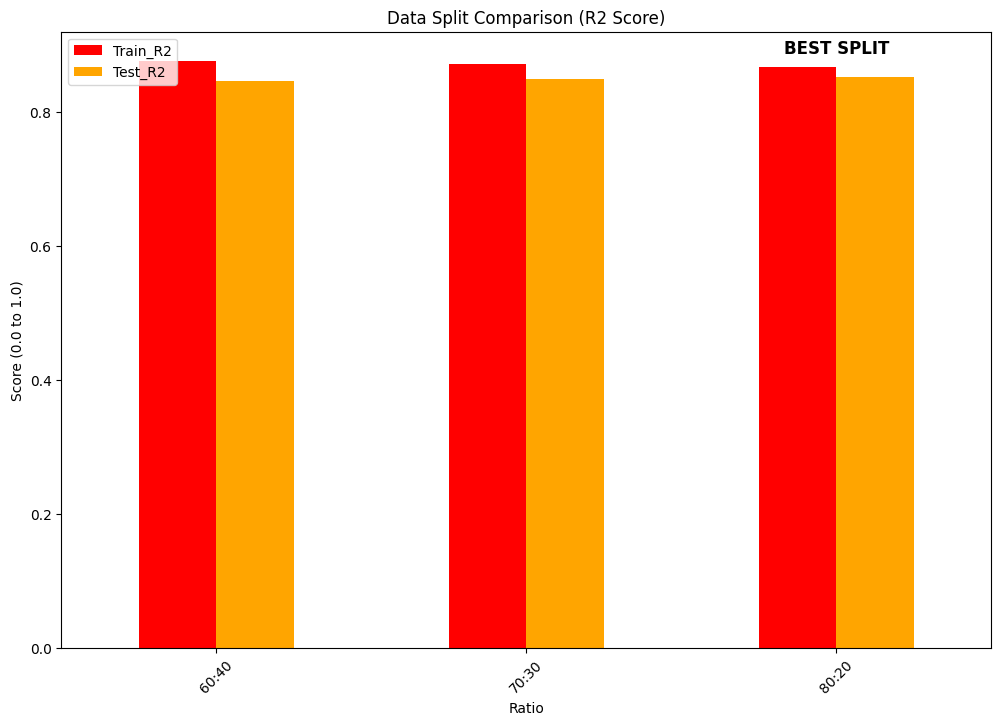

In [4]:
data = {
    'Ratio': ['60:40', '70:30', '80:20'],
    'Train_R2': train_scores,
    'Test_R2': test_scores,
}

df_results = pd.DataFrame(data)




ax = df_results.plot(
    x='Ratio',
    y=['Train_R2', 'Test_R2'],
    kind='bar',
    figsize=(12, 8),
    color=['red', 'orange']
)

plt.title('Data Split Comparison (R2 Score)')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(rotation=45)

last_x = len(df_results) - 1

y_max = max(df_results['Train_R2'].iloc[-1], df_results['Test_R2'].iloc[-1])


plt.text(
    last_x,
    y_max + 0.02,
    "BEST SPLIT",
    ha='center',
    fontsize=12,
    fontweight='bold'
)

plt.show()

In [5]:
y_log = np.log1p(df['SalePrice']) 
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

fin_model = LinearRegression()
fin_model .fit(X_train, y_train_log)
y_pred_log=fin_model.predict(X_test)
# convert back
y_train_original = np.expm1(y_train_log)
y_test_original = np.expm1(y_test_log)
y_pred_original = np.expm1(y_pred_log)

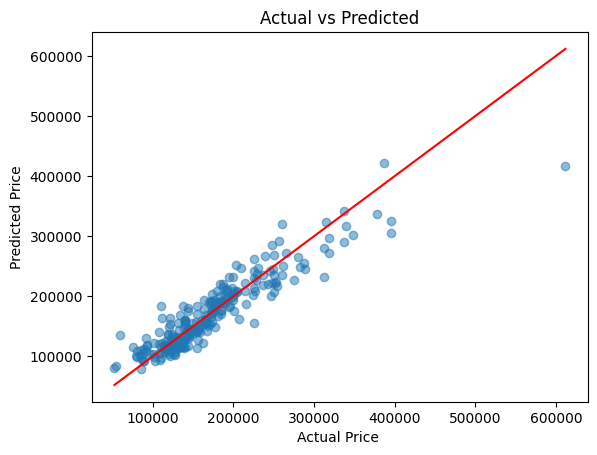

In [6]:
# linear regression
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], color='red')
plt.xlabel("Actual Price ")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [10]:
def get_user_input(features):
    user_data = {}
    
    input_guides = {
        'area_sqft': ("Enter area (500-5000): ", 500, 10000),
        'bedrooms': ("Number of bedrooms (1-6): ", 1, 10),
        'bathrooms': ("Number of bathrooms (1-5): ", 1, 8),
        'floors': ("Number of floors (1-3): ", 1, 5),
        'property_age': ("Age in years (0 for new): ", 0, 200),
        'renovation_status': ("Renovation (0: None, 10: Full): ", 0, 10),
        'lot_size': ("Lot size sqft: ", 1, 100000),
        'neighborhood_score': ("Neighborhood (1-10): ", 1, 10),
        'school_rating': ("School quality (1-10): ", 1, 10),
        'parking_availability': ("Parking? (1: Yes, 0: No): ", 0, 1),
        'construction_quality': ("Build quality (1-10): ", 1, 10),
        'water_supply_score': ("Water reliability (1-10): ", 1, 10),
        'green_space_index': ("Parks/Nature (1-10): ", 1, 10),
        'Fireplaces': ("Fireplaces (0, 1, or 2): ", 0, 5),
        'property_type_Duplex': ("Is it a Duplex? (1: Yes, 0: No): ", 0, 1)
    }

    print("\n House Valuation System (Validation Enabled)")
    print("-" * 55)
    
    for feature in features:
        while True:
            try:
                guide_text, min_val, max_val = input_guides[feature]
            
                if feature == 'lot_size':
                    current_area = user_data.get('area_sqft', 0)
                    prompt = f"➤ Enter Lot Size (Must be at least {current_area} sqft): "
                    value = float(input(prompt))
                    if value < current_area:
                        print(f"    Invalid! Lot size cannot be smaller than the house area ({current_area}).")
                        continue
                else:
                    value = float(input(f"{guide_text}"))
            
                if min_val <= value <= max_val:
                    user_data[feature] = value
                    break
                else:
                    print(f"    Out of range! Please enter a value between {min_val} and {max_val}.")
            except ValueError:
                print("    Error: Please enter a numeric value.")
                
    return user_data 

def predict_with_range(input_data):
   
    input_df = pd.DataFrame([input_data])[X.columns]
    
    # Get prediction 
    log_pred = fin_model.predict(input_df)
    base_price = np.expm1(log_pred)[0]
    
    # MAE 
    mae_value = 18541.37
    lower_bound = base_price - mae_value
    upper_bound = base_price + mae_value
    
    return base_price, lower_bound, upper_bound


user_house = get_user_input(X.columns)
estimated_value, low, high = predict_with_range(user_house)


print("\n" + "="*45)
print("         OFFICIAL VALUATION REPORT")
print("="*45)
print(f"{'Property Feature':<25} | {'Input Value':<12}")
print("-" * 45)

for feat, val in user_house.items():
    clean_name = feat.replace('_', ' ').title()
    display_val = f"{int(val)}" if val == int(val) else f"{val:.1f}"
    print(f"{clean_name:<25} | {display_val:<12}")

print("-" * 45)
print(f"ESTIMATED MARKET VALUE: ${estimated_value:,.2f}")
print(f"LIKELY PRICE RANGE:    ${max(0, low):,.2f} - ${high:,.2f}")
print("-" * 45)
print("Generated by AIML Property Valuation Model")
print("="*45)


🏠 House Valuation System (Validation Enabled)
-------------------------------------------------------


➤ Enter area (500-5000):  3500
➤ Number of bedrooms (1-6):  3
➤ Number of bathrooms (1-5):  3
➤ Number of floors (1-3):  2
➤ Age in years (0 for new):  5
➤ Renovation (0: None, 10: Full):  7
➤ Enter Lot Size (Must be at least 3500.0 sqft):  5000
➤ Neighborhood (1-10):  8
➤ School quality (1-10):  7
➤ Parking? (1: Yes, 0: No):  1
➤ Build quality (1-10):  6
➤ Water reliability (1-10):  9
➤ Parks/Nature (1-10):  8
➤ Fireplaces (0, 1, or 2):  2
➤ Is it a Duplex? (1: Yes, 0: No):  0



         OFFICIAL VALUATION REPORT
Property Feature          | Input Value 
---------------------------------------------
Area Sqft                 | 3500        
Bedrooms                  | 3           
Bathrooms                 | 3           
Floors                    | 2           
Property Age              | 5           
Renovation Status         | 7           
Lot Size                  | 5000        
Neighborhood Score        | 8           
School Rating             | 7           
Parking Availability      | 1           
Construction Quality      | 6           
Water Supply Score        | 9           
Green Space Index         | 8           
Fireplaces                | 2           
Property Type Duplex      | 0           
---------------------------------------------
ESTIMATED MARKET VALUE: $495,113.23
LIKELY PRICE RANGE:    $476,571.86 - $513,654.60
---------------------------------------------
Generated by AIML Property Valuation Model
